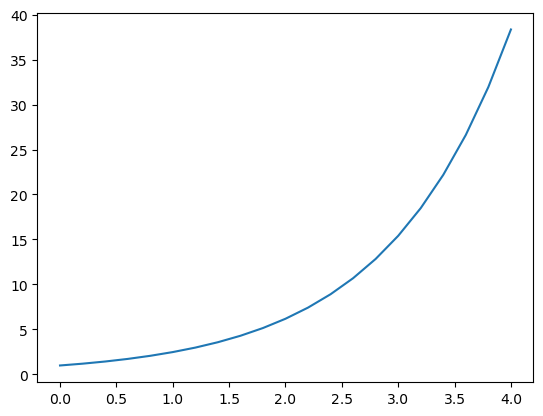

In [2]:
import numpy as np
import matplotlib.pyplot as plt
N = 20
T = 4
dt = T/N
u0 = 1
t = np.zeros(N + 1)
u = np.zeros(N + 1)
u[0] = u0
for n in range(N):
    t[n + 1] = t[n] + dt
    u[n + 1] = (1 + dt) * u[n]
plt.plot(t, u)
plt.show()

In [4]:
import numpy as np
def forward_euler(f, u0, T, N):
    """Solve u’=f(t, u), u(0)=u0, with n steps until t=T."""
    t = np.zeros(N + 1)
    u = np.zeros(N + 1) # u[n] is the solution at time t[n]
    u[0] = u0
    dt = T / N
    for n in range(N):
        t[n + 1] = t[n] + dt
        u[n + 1] = u[n] + dt * f(t[n], u[n])
    return t, u

In [5]:
def f(t, u):
    return u
u0 = 1
T = 4
N = 30
t, u = forward_euler(f, u0, T, N)

In [9]:
import numpy as np

class ForwardEuler_v0:
    def __init__(self, f):
        self.f = f
    def set_initial_condition(self, u0):
        self.u0 = u0
    def solve(self, t_span, N):
        """Compute solution for t_span[0] <= t <= t_span[1],
        using N steps."""
        t0, T = t_span
        self.dt = T / N
        self.t = np.zeros(N + 1) # N steps ~ N+1 time points
        self.u = np.zeros(N + 1)
        msg = "Please set initial condition before calling solve"
        assert hasattr(self, "u0"), msg
        self.t[0] = t0
        self.u[0] = self.u0
        for n in range(N):
            self.n = n
            self.t[n + 1] = self.t[n] + self.dt
            self.u[n + 1] = self.advance()
            return self.t, self.u
    def advance(self):
        """Advance the solution one time step."""
        # Create local variables to get rid of "self." in
        # the numerical formula
        u, dt, f, n, t = self.u, self.dt, self.f, self.n, self.t
        return u[n] + dt * f(t[n], u[n])

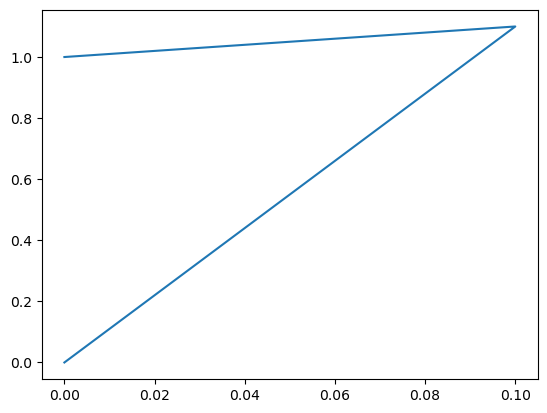

In [12]:
import matplotlib.pyplot as plt
u0 = 1
#T = 4
#N = 30
#t, u = forward_euler(f, u0, T, N)

method = ForwardEuler_v0(f)
method.set_initial_condition(u0)
t, u = method.solve(t_span=(0, 10), N=100)
plt.plot(t, u)

In [14]:
def add(*args):
    print(args)

    return sum(args)



print(add(1, 2))

print(add(1, 2, 3, 4))


(1, 2)
3
(1, 2, 3, 4)
10


In [20]:
def show(*args):
    for i, value in enumerate(args):
        print(i, value)
    
show("A", "B", "C")

0 A
1 B
2 C


In [23]:
def show(**kwargs):
    print(kwargs)
    
show(name="Li", age="40")

{'name': 'Li', 'age': '40'}


In [27]:
def show(**kwargs):
    print(kwargs["name"])
show(name="Li", age="40")

Li


In [30]:
def person(name, **kwargs):
    print("Name:", name)

    for k, v in kwargs.items():
        print(k, v)

person("Li",age="40", city="Ottawa")

Name: Li
age 40
city Ottawa
